In [1]:
import polars as pl
import pandas as pd
import seaborn as sns
import numpy as np
import matplotlib.pyplot as plt
import statsmodels.tsa.api as sts

from scipy.stats import zscore
from polars import DataFrame
from pathlib import Path
from datetime import date
from sklearn.preprocessing import normalize, Normalizer, MinMaxScaler, StandardScaler
from statsmodels.tsa.api import seasonal_decompose

In [2]:
# Carregando os dados de penalidades aplicadas a operadoras com scan (LazyFrame - não materializa o DataFrame imediatamente)
lf_origem_penalidades_aplicadas_a_operadoras = pl.scan_parquet(r"c:\GIT\DadosANS\Cargas\processamentos\penalidades_20260511_213501\ingestao\downloads\penalidades_aplicadas_a_operadoras.parquet")

# collect_schema() é usado para obter o esquema do LazyFrame sem materializar os dados; 
# O método .columns() é mais custoso em recursos, pois pode exigir a leitura de uma amostra dos dados para inferir os tipos de coluna.
# O método .names() retorna apenas os nomes das colunas consultando o schema, o que é mais leve.
lf_origem_penalidades_aplicadas_a_operadoras.collect_schema().names()

['NR_DEMANDA',
 'NR_PROCESSO',
 'TIPO_PROCESSO',
 'OBJETO',
 'REGISTRO_OPERADORA',
 'CNPJ',
 'RAZAO_SOCIAL',
 'SITUACAO_OPERADORA',
 'STATUS_DEMANDA',
 'DT_DECISAO_1A',
 'DT_PUBLICACAO_1A',
 'DT_PUBLICACAO_1A_FINAL',
 'VL_MULTA_FIXA_1A',
 'VL_MULTA_DIARIA_1A',
 'VL_TOTAL_APLICADO_1A',
 'DT_CIENCIA_RECONSIDERA_TOTAL',
 'DT_DECISAO_2A',
 'DT_PUBLICACAO_2A',
 'TIPO_DECISAO_2A',
 'VL_MULTA_FIXA_2A',
 'VL_MULTA_DIARIA_2A',
 'VL_TOTAL_APLICADO_2A',
 'VL_MULTA_FINAL_APLICADA',
 'VL_TOTAL_DESCONTOS',
 'DT_ARQUIVAMENTO',
 'MOTIVO_ARQUIVAMENTO',
 'TIPO_PENALIDADE',
 'DT_SUSPENSAO_ADM',
 'DT_SUSPENSAO_JUD',
 'NR_GRU',
 'DT_VENC_GRU',
 'VL_GRU',
 'DE_SITUACAO_GRU',
 'DT_PAGTO_A_VISTA_ANS',
 'VL_PAGO_A_VISTA_ANS',
 'DT_VENC_1A_PARC_ANS',
 'VL_PARCELAS_ANS_PAGAS',
 'STATUS_PARCELAMENTO',
 'DT_INSCRICAO',
 'INSCRITO_DA',
 'ORIGEM_PAGAMENTO',
 'NR_COMPETENCIA_CARGA']

In [3]:
# Definição das colunas de possível interesse para a análise
colunas_desejaveis_penalidades = [
    'NR_DEMANDA',
    'NR_PROCESSO',
    'TIPO_PROCESSO',
    'REGISTRO_OPERADORA',
    'STATUS_DEMANDA',
    'DT_PUBLICACAO_1A_FINAL',
    'VL_MULTA_FIXA_1A',
    'VL_TOTAL_APLICADO_1A',
    'DT_CIENCIA_RECONSIDERA_TOTAL',
    'TIPO_DECISAO_2A',
    'VL_MULTA_FIXA_2A',
    'VL_TOTAL_APLICADO_2A',
    'VL_MULTA_FINAL_APLICADA',
    'VL_TOTAL_DESCONTOS',
    'DT_ARQUIVAMENTO',
    'MOTIVO_ARQUIVAMENTO',
    'TIPO_PENALIDADE',
    'DT_SUSPENSAO_ADM',
    'DT_SUSPENSAO_JUD',
    'DT_VENC_GRU',
    'VL_GRU',
    'DE_SITUACAO_GRU',
    'DT_PAGTO_A_VISTA_ANS',
    'VL_PAGO_A_VISTA_ANS',
    'DT_INSCRICAO',
    'INSCRITO_DA',
    'ORIGEM_PAGAMENTO',
    'NR_COMPETENCIA_CARGA',
]
# Definição de variável geral para o registro da operadora específica (SC - 312924)
SC = 312924

# Filtragem dos dados para a operadora específica (registro 312924 - SC)
# Seleção das colunas de interesse
# Materializando o DataFrame com collect() - pois já filtramos e selecionamos as colunas, então o resultado deve ser mais leve para a memória
penalidades_sc = (
    lf_origem_penalidades_aplicadas_a_operadoras
    .filter(pl.col("REGISTRO_OPERADORA") == SC)
    .select(colunas_desejaveis_penalidades)
    .collect()
)


In [4]:
# "CAST" ou conversão das colunas de data tipadas como "str" para o tipo "Date" do Polars, usando o formato específico de data presente nos dados ("%d/%m/%Y").
# "CAST" para transformar o Int da coluna VL_PAGO_A_VISTA_ANS em Float.
penalidades_sc = penalidades_sc.with_columns(pl.col(['DT_PUBLICACAO_1A_FINAL',
                                                    'DT_CIENCIA_RECONSIDERA_TOTAL',
                                                    'DT_SUSPENSAO_ADM',
                                                    'DT_SUSPENSAO_JUD',
                                                    'DT_VENC_GRU',
                                                    'DT_PAGTO_A_VISTA_ANS',
                                                    'DT_INSCRICAO',
                                                    'DT_ARQUIVAMENTO'])
                                                    .str.strptime(pl.Date, "%d/%m/%Y", exact=False, strict=False),
                                             pl.col('VL_PAGO_A_VISTA_ANS')
                                                    .cast(pl.Float64())
                                             )

# Confirmando a conversão
penalidades_sc.show()

NR_DEMANDA,NR_PROCESSO,TIPO_PROCESSO,REGISTRO_OPERADORA,STATUS_DEMANDA,DT_PUBLICACAO_1A_FINAL,VL_MULTA_FIXA_1A,VL_TOTAL_APLICADO_1A,DT_CIENCIA_RECONSIDERA_TOTAL,TIPO_DECISAO_2A,VL_MULTA_FIXA_2A,VL_TOTAL_APLICADO_2A,VL_MULTA_FINAL_APLICADA,VL_TOTAL_DESCONTOS,DT_ARQUIVAMENTO,MOTIVO_ARQUIVAMENTO,TIPO_PENALIDADE,DT_SUSPENSAO_ADM,DT_SUSPENSAO_JUD,DT_VENC_GRU,VL_GRU,DE_SITUACAO_GRU,DT_PAGTO_A_VISTA_ANS,VL_PAGO_A_VISTA_ANS,DT_INSCRICAO,INSCRITO_DA,ORIGEM_PAGAMENTO,NR_COMPETENCIA_CARGA
i64,str,str,i64,str,date,i64,i64,date,str,i64,i64,i64,i64,date,str,str,date,date,date,i64,str,date,f64,date,str,str,i64
5379468,"""33910.004280/2022-35""","""Consumidor""",312924,"""Arquivado""",2023-06-25,88000,88000,null,null,0,0,88000,17600,2024-02-27,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2023-08-16,70400,"""Pago""",2023-08-16,70400.0,null,"""NAO""","""ANS""",202503
3419328,"""33903.003604/2017-40""","""Consumidor""",312924,"""Arquivado""",2017-05-23,66000,66000,null,"""Provimento Negado""",0,0,0,null,2020-09-24,"""Extinção do Processo (Artigo 5…","""Multa Pecuniária""",null,2019-03-15,2019-02-28,73240,"""Cancelada""",null,null,null,"""NAO""","""ANS""",202503
1664105,"""25785.014384/2012-31""","""Consumidor""",312924,"""Em Cobrança""",2015-08-11,72650,72650,null,"""Provimento Negado""",72650,72650,72650,null,null,null,"""Multa Pecuniária""",null,2017-05-17,2017-01-31,99916,"""Suspenso""",null,null,2017-04-03,"""SIM""","""DA""",202503
2580639,"""25782.009138/2015-30""","""Consumidor""",312924,"""Arquivado""",2016-11-03,66000,66000,null,"""Provimento Negado""",66000,66000,66000,null,2022-10-27,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2019-02-28,90625,"""Pago""",2020-10-06,99239.0,null,"""NAO""","""ANS""",202503
4431631,"""33910.026096/2019-41""","""Consumidor""",312924,"""Arquivado""",2022-04-06,79200,79200,null,null,0,0,79200,15840,2024-02-20,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2023-02-10,63360,"""Pago""",2023-02-10,63360.0,null,"""NAO""","""ANS""",202503


In [5]:
# Análise exploratória: total de multas pago a vista por ano de pagamento
consulta_valor_ano = penalidades_sc.group_by(pl.col("DT_PAGTO_A_VISTA_ANS")
                                             .dt
                                             .year()
                                             .alias("ANO_PAGTO")
                                             ).agg(pl.col("VL_PAGO_A_VISTA_ANS")
                                                                     .sum()
                                                                     .alias("TOTAL_ANO_PAGTO")
                                                                     ).sort("ANO_PAGTO")

consulta_valor_ano.show(14)


ANO_PAGTO,TOTAL_ANO_PAGTO
i32,f64
null,0.0
2013,126041.0
2014,170918.0
2015,185878.0
2016,711519.0
2017,995493.0
2018,4.436404e6
2019,3.991809e6
2020,1.966389e6


As informações geradas sugerem uma diminuição maior que 50% das multas pagas entre 2024 e 2025, é necessário investigar.

In [6]:
penalidades_sc.filter(pl.col("DT_PAGTO_A_VISTA_ANS").dt.year() >= 2024).sort("DT_PAGTO_A_VISTA_ANS").show(limit=None)

NR_DEMANDA,NR_PROCESSO,TIPO_PROCESSO,REGISTRO_OPERADORA,STATUS_DEMANDA,DT_PUBLICACAO_1A_FINAL,VL_MULTA_FIXA_1A,VL_TOTAL_APLICADO_1A,DT_CIENCIA_RECONSIDERA_TOTAL,TIPO_DECISAO_2A,VL_MULTA_FIXA_2A,VL_TOTAL_APLICADO_2A,VL_MULTA_FINAL_APLICADA,VL_TOTAL_DESCONTOS,DT_ARQUIVAMENTO,MOTIVO_ARQUIVAMENTO,TIPO_PENALIDADE,DT_SUSPENSAO_ADM,DT_SUSPENSAO_JUD,DT_VENC_GRU,VL_GRU,DE_SITUACAO_GRU,DT_PAGTO_A_VISTA_ANS,VL_PAGO_A_VISTA_ANS,DT_INSCRICAO,INSCRITO_DA,ORIGEM_PAGAMENTO,NR_COMPETENCIA_CARGA
i64,str,str,i64,str,date,i64,i64,date,str,i64,i64,i64,i64,date,str,str,date,date,date,i64,str,date,f64,date,str,str,i64
5729924,"""33910.010793/2023-66""","""Consumidor""",312924,"""Arquivado""",2023-09-18,33000,33000,null,null,0,0,33000,6600,2024-04-05,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-01-15,26400,"""Pago""",2024-01-11,26400.0,null,"""NAO""","""ANS""",202503
5707875,"""33910.006662/2023-84""","""Consumidor""",312924,"""Arquivado""",2023-09-05,66000,66000,null,null,0,0,66000,13200,2024-04-05,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-01-15,52800,"""Pago""",2024-01-11,52800.0,null,"""NAO""","""ANS""",202503
5764359,"""33910.013807/2023-01""","""Consumidor""",312924,"""Arquivado""",2023-11-09,30000,30000,null,null,0,0,30000,6000,2024-01-25,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-01-17,24000,"""Pago""",2024-01-16,24000.0,null,"""NAO""","""ANS""",202503
5751718,"""33910.011975/2023-54""","""Consumidor""",312924,"""Arquivado""",2023-09-14,80000,80000,null,null,0,0,80000,32000,2024-01-22,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-01-18,48000,"""Pago""",2024-01-16,48000.0,null,"""NAO""","""ANS""",202503
5185000,"""33910.032791/2021-66""","""Consumidor""",312924,"""Arquivado""",2023-08-24,60000,60000,null,null,0,0,60000,12000,2024-06-12,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-01-17,48000,"""Pago""",2024-01-17,48000.0,null,"""NAO""","""ANS""",202503
5428684,"""33910.021611/2022-00""","""Consumidor""",312924,"""Arquivado""",2023-05-15,79200,79200,null,"""Provimento Negado""",79200,79200,79200,null,2024-03-20,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-01-31,84736,"""Pago""",2024-01-31,84736.0,null,"""NAO""","""ANS""",202503
5579433,"""33910.033562/2022-40""","""Consumidor""",312924,"""Arquivado""",2023-12-28,60000,60000,null,null,0,0,60000,24000,2024-03-04,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-02-14,36000,"""Pago""",2024-02-09,36000.0,null,"""NAO""","""ANS""",202503
5896923,"""33910.036179/2023-24""","""Consumidor""",312924,"""Arquivado""",2024-01-11,30000,30000,null,null,0,0,30000,12000,2024-03-25,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-02-20,18000,"""Pago""",2024-02-20,18000.0,null,"""NAO""","""ANS""",202503
4986073,"""33910.006580/2021-78""","""Consumidor""",312924,"""Arquivado""",2023-12-06,88000,88000,null,null,0,0,88000,17600,2024-04-11,"""Decisão condenatória com pagam…","""Multa Pecuniária""",null,null,2024-02-21,70400,"""Pago""",2024-02-20,70400.0,null,"""NAO""","""ANS""",202503


In [7]:
penalidades_sc.null_count()

NR_DEMANDA,NR_PROCESSO,TIPO_PROCESSO,REGISTRO_OPERADORA,STATUS_DEMANDA,DT_PUBLICACAO_1A_FINAL,VL_MULTA_FIXA_1A,VL_TOTAL_APLICADO_1A,DT_CIENCIA_RECONSIDERA_TOTAL,TIPO_DECISAO_2A,VL_MULTA_FIXA_2A,VL_TOTAL_APLICADO_2A,VL_MULTA_FINAL_APLICADA,VL_TOTAL_DESCONTOS,DT_ARQUIVAMENTO,MOTIVO_ARQUIVAMENTO,TIPO_PENALIDADE,DT_SUSPENSAO_ADM,DT_SUSPENSAO_JUD,DT_VENC_GRU,VL_GRU,DE_SITUACAO_GRU,DT_PAGTO_A_VISTA_ANS,VL_PAGO_A_VISTA_ANS,DT_INSCRICAO,INSCRITO_DA,ORIGEM_PAGAMENTO,NR_COMPETENCIA_CARGA
u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,384,248,0,0,0,215,59,59,0,384,351,44,44,44,83,83,353,0,44,0


# A última data de pagamento para o ano de 2025 foi registrada em 10/03/2025

1. Será necessário estimar os valores do ano de 2025 com base no primeiro bimestre do ano e anos anteriores;
2. Descartar Regressão Linear - o histórico de pagamento de multas de anos anteriores demonstra uma relação não linear entre eles;
3. Descartar Regressão Polinomial - a variação positiva e negativa geraria uma equação com muitas curvas, tornando o modelo desnecessariamente complexo;
4. Investigar correlação entre IGR e valores de multa pagos.

# Investigação da correlação entre o IGR e as penalidades aplicadas no mesmo período.

## Fase 1: Preparação das bases para investigação de correlação:


In [8]:
'''
1. select() - seleciona apenas as colunas relevantes para a análise de correlação;

2. drop_nulls() - elimina os valores nulos - há decisões de 1A que foram revistas, suspensas ou canceladas, resultando em valor nulo para as demais colunas;

3. filter() - filtra para as decisões tomadas após 2018 (antes disso os prazos entre 1A e PAGTO não eram homogêneos)

'''
visualiza_periodo_decisao_pagamento = penalidades_sc.select(pl.col(
                                            [
                                            'DT_PUBLICACAO_1A_FINAL',
                                            'DT_PAGTO_A_VISTA_ANS',
                                            'VL_PAGO_A_VISTA_ANS'
                                            ])
                                            ).drop_nulls(
                                                ).filter(
                                                    (pl.col('DT_PUBLICACAO_1A_FINAL') > date(2017,12,31))
                                                    ).sort('DT_PUBLICACAO_1A_FINAL', 
                                                       descending=True
                                                       )

visualiza_periodo_decisao_pagamento

DT_PUBLICACAO_1A_FINAL,DT_PAGTO_A_VISTA_ANS,VL_PAGO_A_VISTA_ANS
date,date,f64
2025-01-20,2025-03-10,48000.0
2025-01-13,2025-02-18,48000.0
2024-12-26,2025-02-17,70400.0
2024-12-20,2025-02-12,48000.0
2024-12-10,2025-02-06,70400.0
…,…,…
2018-03-02,2018-06-22,80203.0
2018-02-06,2018-07-26,110304.0
2018-02-06,2018-06-12,80816.0


In [9]:
# Calcula a quantidade de dias decorridos entre a primeira decisão da ANS e o pagamento da multa
prazo_finalizacao = visualiza_periodo_decisao_pagamento.with_columns(
                        (pl.col("DT_PAGTO_A_VISTA_ANS") - pl.col('DT_PUBLICACAO_1A_FINAL')).alias('PRAZO_FINALIZACAO')
                        ) 

''' 
Vamos precisar desse dado quando formos analisar a relação entre as linhas das duas variáveis porque há um delay(lag) entre a decisão e seu efetivo pagamento, 
então uma multa x normalmente é aplicada em d + l (data + lag); sem considerar o lag, ao comparar com o registro do IGR, teríamos um descompasso entre as datas das multas e
o IGR registrado no mês de referência.

'''
# Calcula a mediana da coluna "PRAZO_FINALIZACAO"
# A mediana é preferível em relação à média porque suaviza o impacto dos valores extremos
tempo_medio_pagamento = prazo_finalizacao['PRAZO_FINALIZACAO'].median()
tempo_medio_pagamento

datetime.timedelta(days=62)

In [10]:
# Expressão para criar uma coluna com a úlima data do mês tendo como referência cada linha da coluna "DT_PUBLICACAO_1A_FINAL"
mes_pagamento_expr = (
    pl.col("DT_PUBLICACAO_1A_FINAL")
    .dt.month_end()
    .alias("MES_PAGAMENTO")
)

# Expressão que cria a agregação de soma da coluna "VL_PAGO_A_VISTA_ANS"
valor_mes_expr = (
    pl.col("VL_PAGO_A_VISTA_ANS")
    .sum()
    .alias("VALOR_MES")
)
'''
Utilização das expressões criadas acima que resulta no agrupamento das datas da coluna "MES_PAGAMENTO" em periodicidade mensal e agregação de soma da coluna "VL_PAGO_A_VISTA_ANS".

O resultado é o valor total de multas pago dentro do mês de referência.

'''
visualiza_periodo_decisao_pagamento_mensal = (
    visualiza_periodo_decisao_pagamento
    .group_by(
        mes_pagamento_expr,
    )
    .agg(valor_mes_expr)
    .sort(["MES_PAGAMENTO"])
)

visualiza_periodo_decisao_pagamento_mensal

MES_PAGAMENTO,VALOR_MES
date,f64
2018-01-31,178161.0
2018-02-28,191120.0
2018-03-31,338168.0
2018-04-30,259081.0
2018-05-31,313322.0
…,…
2024-08-31,249920.0
2024-10-31,315600.0
2024-11-30,70400.0


In [11]:
# Carrega a base do IGR
igr = pl.scan_parquet(r'C:\GIT\DadosANS\Finalizados\mescla_IGR.parquet')

# Novamente, utilizamos as funcionalidades do LazyFrame para descobrir os nomes e tipos das colunas sem materializar o df
igr.collect_schema(), igr.show()


REGISTRO_ANS,RAZAO_SOCIAL,COBERTURA,IGR,QTD_RECLAMACOES,QTD_BENEFICIARIOS,PORTE_OPERADORA,COMPETENCIA,COMPETENCIA_BENEFICIARIO,DT_ATUALIZACAO,arquivo_origem,grupo_mescla
i64,str,str,str,i64,i64,str,i64,i64,str,str,str
312924,"""CAIXA ECONÔMICA FEDERAL""","""Assistência médica""","""111,63""",306,274114,"""Grande""",202604,202603,"""2026-05-07""","""IGR.csv""","""IGR"""
312924,"""CAIXA ECONÔMICA FEDERAL""","""Assistência médica""","""109,44""",300,274114,"""Grande""",202603,202603,"""2026-05-07""","""IGR.csv""","""IGR"""
312924,"""CAIXA ECONÔMICA FEDERAL""","""Assistência médica""","""74,30""",204,274570,"""Grande""",202602,202602,"""2026-05-07""","""IGR.csv""","""IGR"""
312924,"""CAIXA ECONÔMICA FEDERAL""","""Assistência médica""","""75,27""",207,274998,"""Grande""",202601,202601,"""2026-05-07""","""IGR.csv""","""IGR"""
312924,"""CAIXA ECONÔMICA FEDERAL""","""Assistência médica""","""118,68""",327,275536,"""Grande""",202512,202512,"""2026-05-07""","""IGR.csv""","""IGR"""


(Schema([('REGISTRO_ANS', Int64),
         ('RAZAO_SOCIAL', String),
         ('COBERTURA', String),
         ('IGR', String),
         ('QTD_RECLAMACOES', Int64),
         ('QTD_BENEFICIARIOS', Int64),
         ('PORTE_OPERADORA', String),
         ('COMPETENCIA', Int64),
         ('COMPETENCIA_BENEFICIARIO', Int64),
         ('DT_ATUALIZACAO', String),
         ('arquivo_origem', String),
         ('grupo_mescla', String)]),
 None)

In [12]:
'''
 A nossa coluna de data, que será a referência para a comparação com o df das multas, está no formato INT, o que impossibilita a utilização de funções e métodos de data,
 em razão disso será necessário alterá-la primeiro para STRING, depois utilizar uma função de STRING para extrair a data no formato desejado (pl.Date) e jogar para o último dia do mês,
 exatamente como fizemos no dataset das multas/penalidades.
 
 Já a coluna "IGR", além de estar no formato STRING, contém o caractere ",", que pra nós é indicador de numeração decimal, mas para o python signfica milhar, então é necessário retirá-lo
 enquanto transformamos o tipo da coluna em FLOAT.
'''
igr = igr.with_columns(
                    (pl.col('COMPETENCIA').cast(str).str.strptime(pl.Date, '%Y%m').dt.month_end()),
                    (pl.col('IGR').str.replace(',', '.').cast(pl.Float64))
                    )

# Seleção das colunas desejáveis
colunas_desejaveis_igr =['COMPETENCIA', 'IGR', 'QTD_RECLAMACOES']

# Seleciona as colunas desejáveis e materializa o df com .collect().
# O select() cria um novo df, sem alterar o original; agora podemos utilizar o collect() porque já fizemos a filtragem somente das colunas que vamos utilizar.
igr = igr.select(colunas_desejaveis_igr).collect()


In [13]:
# Precisamos utilizar apenas as datas que têm correspondência entre os 2 dfs, para isso aplicamos esses filtros
igr_comparavel = igr.filter(
                        (pl.col('COMPETENCIA') > date(2017,12,31))& 
                        (pl.col('COMPETENCIA') < date(2025,2,1))
                        )

# Visualização das 2 tabelas preparadas para a próxima fase
igr_comparavel, visualiza_periodo_decisao_pagamento_mensal

(shape: (85, 3)
 ┌─────────────┬───────┬─────────────────┐
 │ COMPETENCIA ┆ IGR   ┆ QTD_RECLAMACOES │
 │ ---         ┆ ---   ┆ ---             │
 │ date        ┆ f64   ┆ i64             │
 ╞═════════════╪═══════╪═════════════════╡
 │ 2025-01-31  ┆ 54.61 ┆ 153             │
 │ 2024-12-31  ┆ 45.67 ┆ 128             │
 │ 2024-11-30  ┆ 51.01 ┆ 143             │
 │ 2024-10-31  ┆ 44.92 ┆ 126             │
 │ 2024-09-30  ┆ 42.07 ┆ 118             │
 │ …           ┆ …     ┆ …               │
 │ 2018-05-31  ┆ 28.4  ┆ 82              │
 │ 2018-04-30  ┆ 50.6  ┆ 146             │
 │ 2018-03-31  ┆ 79.3  ┆ 229             │
 │ 2018-02-28  ┆ 32.2  ┆ 93              │
 │ 2018-01-31  ┆ 32.9  ┆ 95              │
 └─────────────┴───────┴─────────────────┘,
 shape: (72, 2)
 ┌───────────────┬───────────┐
 │ MES_PAGAMENTO ┆ VALOR_MES │
 │ ---           ┆ ---       │
 │ date          ┆ f64       │
 ╞═══════════════╪═══════════╡
 │ 2018-01-31    ┆ 178161.0  │
 │ 2018-02-28    ┆ 191120.0  │
 │ 2018-03-31    ┆ 

In [14]:
# Mescla os dfs em um só para facilitar as plotagens;
# O join() não aceita referenciar colunas diferentes, por isso foi necessário renomear a coluna "MES_PAGAMENTO" no decorrer da operação.
dfs_mesclados = igr_comparavel.join(
    visualiza_periodo_decisao_pagamento_mensal.rename({'MES_PAGAMENTO': 'COMPETENCIA'}), 
    'COMPETENCIA', 
    'inner'
).sort(by='COMPETENCIA')
dfs_mesclados

COMPETENCIA,IGR,QTD_RECLAMACOES,VALOR_MES
date,f64,i64,f64
2018-01-31,32.9,95,178161.0
2018-02-28,32.2,93,191120.0
2018-03-31,79.3,229,338168.0
2018-04-30,50.6,146,259081.0
2018-05-31,28.4,82,313322.0
…,…,…,…
2024-08-31,29.19,82,249920.0
2024-10-31,44.92,126,315600.0
2024-11-30,51.01,143,70400.0


## Fase 2: padronização e/ou normalização.

### Qual a diferença entre padronização e normalização?

1. Padronização: transforma o conjunto de forma que sua média se torne o ponto 0 e o desvio padrão seja 1, ou seja, em uma escala de desvios padrão em torno da média. Dessa forma, sua utilidade está em entender e quantificar comportamentos que se distanciam da média do conjunto.Tende a ser especialmente útil em métodos sensíveis à escala das variáveis, incluindo métodos que dependem de variância, covariância, distância ou produtos internos.

2. Normalização: transforma o conjunto em valores que gravitam ao redor de uma faixa fixa, geralmente a escala fica entre 0 e 1; o 0 referencia o menor valor do conjunto e o 1 seu maior valor, os dados são re-escalados conforme sua proximidade entre os valores fixados. Sua utilidade está em facilitar a visualização da evolução relativa dos dados em uma escala comum, facilita a comparação visual de dois conjuntos com amplitudes muito diferentes.

### Por que padronizar ou normalizar?

1. Imagine que você precisa comparar visualmente dois conjuntos de dados com valores mínimos ou amplitudes muito diferentes, para fins de exemplo vamos utilizar Amin=10 e Bmin=10.000: você plota as linhas no gráfico, mas não consegue identificar nada, pois o valor mais alto vai dominar completamente o gráfico, uma vez que sua variação se dá aos milhares, enquanto o outro se dá nas dezenas. A normalização/padronização recria essas escala, aproximando os valores em termos visualizáveis e interpretáveis;

2. Previne distorções em modelos e algoritmos que se utilizam de coordenadas geométricas para seus cálculos. Muitos algoritmos se baseam nas distâncias entre pontos para calcular seus resultados, sem uma padronização/normalização, o algoritmo pode valorizar mais um conjunto com valores nas dezenas de milhares do que aqueles nas dezenas ou centenas, uma vez que as distâncias serão nominalmente maiores no primeiro caso.

3. O mesmo é verdadeiro quanto a modelos que se baseiam em variância e covariância, pois a diferença na variancia nominal em uma variável de valor base maior vai influenciar mais no modelo do que uma variável com base menor.

In [15]:
# Padronização por z-score

# Cria as colunas padronizadas
igr_z = pl.Series(zscore(dfs_mesclados['IGR']))
valor_mes_z = pl.Series(zscore(dfs_mesclados['VALOR_MES']))

# Inclui elas no df
dfs_mesclados = dfs_mesclados.with_columns(
    igr_z.alias('IGR_Z'), 
    valor_mes_z.alias('VALOR_MES_Z')
    )
dfs_mesclados

COMPETENCIA,IGR,QTD_RECLAMACOES,VALOR_MES,IGR_Z,VALOR_MES_Z
date,f64,i64,f64,f64,f64
2018-01-31,32.9,95,178161.0,0.51226,-0.146734
2018-02-28,32.2,93,191120.0,0.452114,-0.068211
2018-03-31,79.3,229,338168.0,4.49912,0.822811
2018-04-30,50.6,146,259081.0,2.03311,0.343592
2018-05-31,28.4,82,313322.0,0.125604,0.67226
…,…,…,…,…,…
2024-08-31,29.19,82,249920.0,0.193483,0.288082
2024-10-31,44.92,126,315600.0,1.545063,0.686063
2024-11-30,51.01,143,70400.0,2.068339,-0.799701


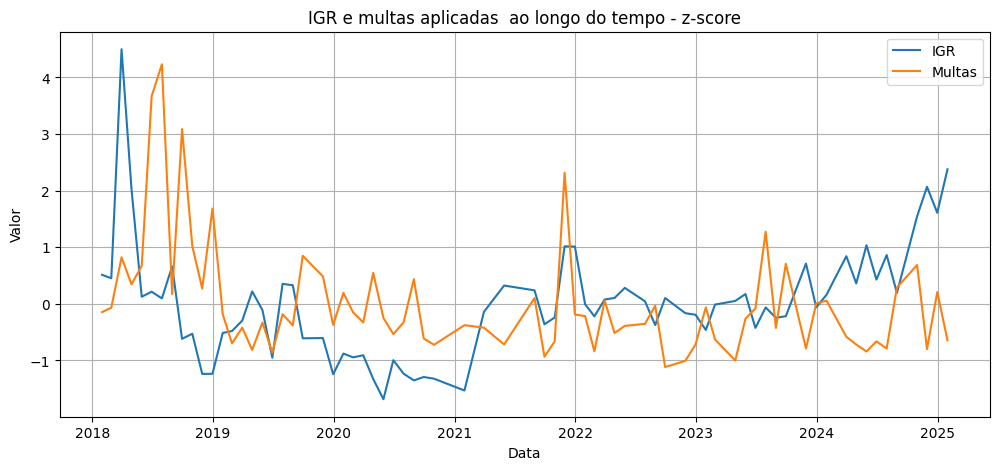

In [16]:
# Plotagem do gráfico com as variáveis padronizadas pelo z-score

# Tamanho da figura na qual o gráfico será plotado
plt.figure(figsize=(12, 5))

# Plot das linhas
plt.plot(dfs_mesclados['COMPETENCIA'], dfs_mesclados["IGR_Z"], label="IGR")
plt.plot(dfs_mesclados['COMPETENCIA'], dfs_mesclados["VALOR_MES_Z"], label="Multas")

# Titulo do gráfico
plt.title("IGR e multas aplicadas  ao longo do tempo - z-score")

# Título do eixo x
plt.xlabel("Data")

# Título do eixo y
plt.ylabel("Valor")

# Acrescenta a legenda - uma para cada variável/coluna
plt.legend()

# Acrescenta o grid ao fundo do gráfico para facilitar a interpretação
plt.grid(True)

# Motra o gráfico conforme a configurações acima
plt.show()

In [17]:
# Normalização Base 100

# Aplica a fórmula da normalização às variáveis e cria novas colunas com elas
dfs_mesclados = dfs_mesclados.with_columns(
                (pl.col('IGR') / pl.col('IGR').first() * 100).alias('IGR_B100'),
                (pl.col('VALOR_MES') / pl.col('VALOR_MES').first() * 100).alias('VALOR_MES_B100')
)
dfs_mesclados


COMPETENCIA,IGR,QTD_RECLAMACOES,VALOR_MES,IGR_Z,VALOR_MES_Z,IGR_B100,VALOR_MES_B100
date,f64,i64,f64,f64,f64,f64,f64
2018-01-31,32.9,95,178161.0,0.51226,-0.146734,100.0,100.0
2018-02-28,32.2,93,191120.0,0.452114,-0.068211,97.87234,107.273758
2018-03-31,79.3,229,338168.0,4.49912,0.822811,241.033435,189.81034
2018-04-30,50.6,146,259081.0,2.03311,0.343592,153.799392,145.419592
2018-05-31,28.4,82,313322.0,0.125604,0.67226,86.322188,175.864527
…,…,…,…,…,…,…,…
2024-08-31,29.19,82,249920.0,0.193483,0.288082,88.723404,140.277614
2024-10-31,44.92,126,315600.0,1.545063,0.686063,136.534954,177.143146
2024-11-30,51.01,143,70400.0,2.068339,-0.799701,155.045593,39.514821


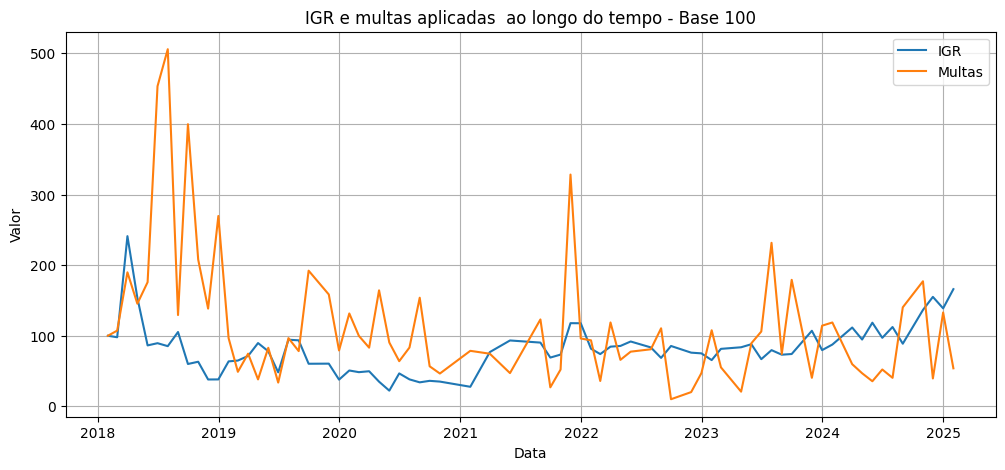

In [18]:
# Gráfico da Normalização Base 100

plt.figure(figsize=(12, 5))
plt.plot(dfs_mesclados['COMPETENCIA'], dfs_mesclados["IGR_B100"], label="IGR")
plt.plot(dfs_mesclados['COMPETENCIA'], dfs_mesclados["VALOR_MES_B100"], label="Multas")

plt.title("IGR e multas aplicadas  ao longo do tempo - Base 100")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

In [19]:
# Normalização Escala Min Max

# Aplicação da fórmula nas colunas e inclusão dos resultados no df
dfs_mesclados = dfs_mesclados.with_columns(
    (
        (pl.col('IGR') - pl.col('IGR').min()) /
        (pl.col('IGR').max() - pl.col('IGR').min())
    ).alias('IGR_MINMAX'),
    (
        (pl.col('VALOR_MES') - pl.col('VALOR_MES').min()) /
        (pl.col('VALOR_MES').max() - pl.col('VALOR_MES').min())
    ).alias('VALOR_MES_MINMAX')
)

dfs_mesclados

COMPETENCIA,IGR,QTD_RECLAMACOES,VALOR_MES,IGR_Z,VALOR_MES_Z,IGR_B100,VALOR_MES_B100,IGR_MINMAX,VALOR_MES_MINMAX
date,f64,i64,f64,f64,f64,f64,f64,f64,f64
2018-01-31,32.9,95,178161.0,0.51226,-0.146734,100.0,100.0,0.355376,0.181367
2018-02-28,32.2,93,191120.0,0.452114,-0.068211,97.87234,107.273758,0.345652,0.196041
2018-03-31,79.3,229,338168.0,4.49912,0.822811,241.033435,189.81034,1.0,0.362559
2018-04-30,50.6,146,259081.0,2.03311,0.343592,153.799392,145.419592,0.601278,0.273
2018-05-31,28.4,82,313322.0,0.125604,0.67226,86.322188,175.864527,0.292859,0.334423
…,…,…,…,…,…,…,…,…,…
2024-08-31,29.19,82,249920.0,0.193483,0.288082,88.723404,140.277614,0.303834,0.262627
2024-10-31,44.92,126,315600.0,1.545063,0.686063,136.534954,177.143146,0.522367,0.337003
2024-11-30,51.01,143,70400.0,2.068339,-0.799701,155.045593,39.514821,0.606974,0.059338


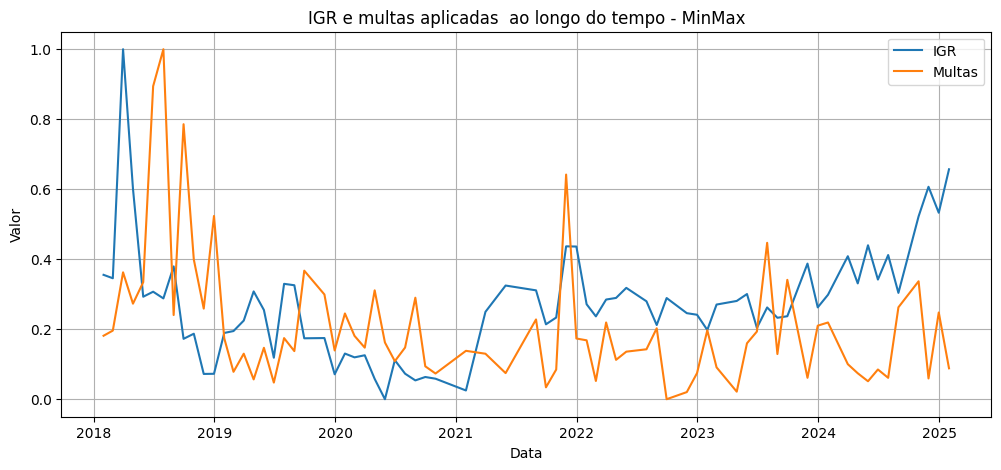

In [20]:
# Gráfico da Normalização MinMax

plt.figure(figsize=(12, 5))
plt.plot(dfs_mesclados['COMPETENCIA'], dfs_mesclados["IGR_MINMAX"], label="IGR")
plt.plot(dfs_mesclados['COMPETENCIA'], dfs_mesclados["VALOR_MES_MINMAX"], label="Multas")

plt.title("IGR e multas aplicadas  ao longo do tempo - MinMax")
plt.xlabel("Data")
plt.ylabel("Valor")
plt.legend()
plt.grid(True)
plt.show()

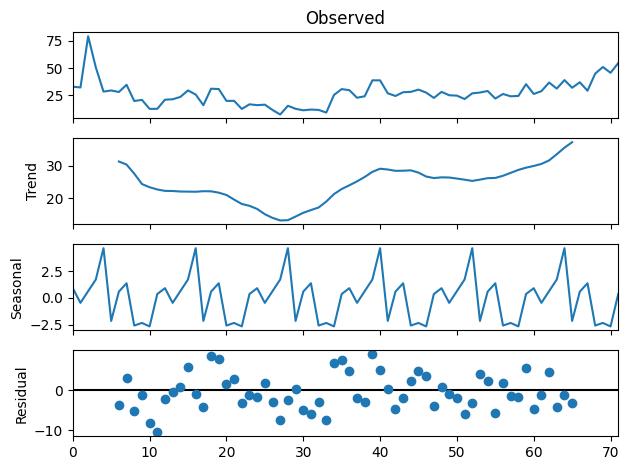

In [21]:
decompose_igr = sts.seasonal_decompose(dfs_mesclados['IGR'], model='aditive', period=12)

decompose_igr.plot()
plt.show()

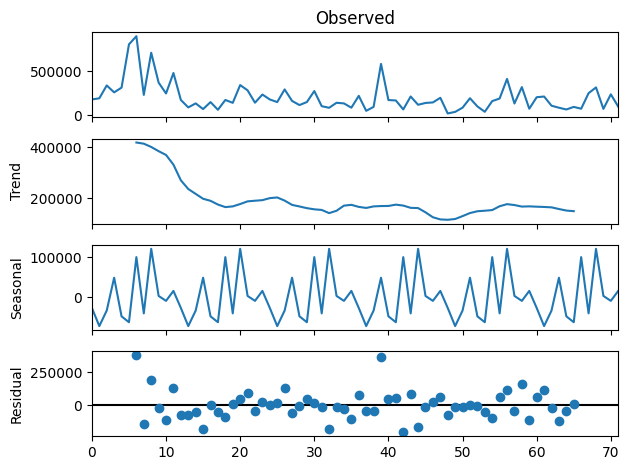

In [22]:
decompose_valor = sts.seasonal_decompose(dfs_mesclados['VALOR_MES'], model='aditive', period=12)

decompose_valor.plot()
plt.show()

In [23]:
np.corrcoef(decompose_igr.seasonal, decompose_valor.seasonal)

array([[ 1.        , -0.20351187],
       [-0.20351187,  1.        ]])

In [24]:
igr_sem_sazonal = pl.Series(decompose_igr.observed - decompose_igr.seasonal)
valor_mes_sem_sazonal = pl.Series(decompose_valor.observed - decompose_valor.seasonal)

dfs_mesclados = dfs_mesclados.with_columns(
                        (igr_sem_sazonal.alias('IGR_SEM_SAZONAL')),
                        (valor_mes_sem_sazonal.alias('VALOR_MES_SEM_SAZONAL'))
                        )

dfs_mesclados

COMPETENCIA,IGR,QTD_RECLAMACOES,VALOR_MES,IGR_Z,VALOR_MES_Z,IGR_B100,VALOR_MES_B100,IGR_MINMAX,VALOR_MES_MINMAX,IGR_SEM_SAZONAL,VALOR_MES_SEM_SAZONAL
date,f64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64
2018-01-31,32.9,95,178161.0,0.51226,-0.146734,100.0,100.0,0.355376,0.181367,31.998903,204677.540278
2018-02-28,32.2,93,191120.0,0.452114,-0.068211,97.87234,107.273758,0.345652,0.196041,32.663819,262854.015278
2018-03-31,79.3,229,338168.0,4.49912,0.822811,241.033435,189.81034,1.0,0.362559,78.672236,371139.498611
2018-04-30,50.6,146,259081.0,2.03311,0.343592,153.799392,145.419592,0.601278,0.273,48.885903,210146.115278
2018-05-31,28.4,82,313322.0,0.125604,0.67226,86.322188,175.864527,0.292859,0.334423,23.765986,360760.248611
…,…,…,…,…,…,…,…,…,…,…,…
2024-08-31,29.19,82,249920.0,0.193483,0.288082,88.723404,140.277614,0.303834,0.262627,27.824736,289909.365278
2024-10-31,44.92,126,315600.0,1.545063,0.686063,136.534954,177.143146,0.522367,0.337003,47.497653,194689.831944
2024-11-30,51.01,143,70400.0,2.068339,-0.799701,155.045593,39.514821,0.606974,0.059338,53.344736,66941.023611


In [25]:
df_numericas = dfs_mesclados.select(pl.selectors.numeric())
df_numericas.corr()

IGR,QTD_RECLAMACOES,VALOR_MES,IGR_Z,VALOR_MES_Z,IGR_B100,VALOR_MES_B100,IGR_MINMAX,VALOR_MES_MINMAX,IGR_SEM_SAZONAL,VALOR_MES_SEM_SAZONAL
f64,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
1.0,0.999625,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.0258,0.983931,0.023823
0.999625,1.0,0.032518,0.999625,0.032518,0.999625,0.032518,0.999625,0.032518,0.982862,0.032052
0.0258,0.032518,1.0,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.049311,0.933864
1.0,0.999625,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.0258,0.983931,0.023823
0.0258,0.032518,1.0,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.049311,0.933864
…,…,…,…,…,…,…,…,…,…,…
0.0258,0.032518,1.0,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.049311,0.933864
1.0,0.999625,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.0258,0.983931,0.023823
0.0258,0.032518,1.0,0.0258,1.0,0.0258,1.0,0.0258,1.0,0.049311,0.933864
